# VFA-1 · Navigating in the Fog
## Conference Demo — Tabular Q-Learning vs Linear Function Approximation

**Three sections:**
1. **Environment Showcase** — step-by-step episode on 10×10 and 25×25 grids
2. **Agent Comparison** — three agents, same randomised map, side-by-side
3. **500-Episode Statistics** — reward curves, termination reasons, learned weights

Run all cells top-to-bottom (`Kernel → Restart & Run All`).

In [ ]:
import sys, pickle
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import Counter

# ─── Project root ─────────────────────────────────────────────────────────
root = Path.cwd()
while not (root / 'src' / 'environment').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.environment.grid_world import FogGridWorld

# ─── Plot style ───────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})

# Colour map  FOG=0 FREE=1 WALL=2 TRAP=3 GOAL=4 ENERGY=5 AGENT=6
_PAL = np.array([
    [ 28,  28,  28],  # FOG
    [240, 240, 224],  # FREE
    [ 96,  96,  96],  # WALL
    [204,  51,  51],  # TRAP
    [ 51, 204,  85],  # GOAL
    [255, 170,   0],  # ENERGY
    [ 51, 153, 255],  # AGENT
]) / 255.0
CMAP = ListedColormap(_PAL)
_LEGEND = [mpatches.Patch(color=_PAL[i], label=lbl)
           for i, lbl in enumerate(['Fog','Free','Wall','Trap','Goal','Energy','Agent'])]

# ─── Load trained agents ──────────────────────────────────────────────────
AGENTS_DIR = root / 'src' / 'experiments' / 'saved_agents'

def _load(pattern):
    files = sorted(AGENTS_DIR.glob(pattern))
    if not files:
        raise FileNotFoundError(f'{pattern} not found in {AGENTS_DIR}')
    with open(files[-1], 'rb') as f:
        return pickle.load(f)

agent_q      = _load('tabular_q_*.pkl')
agent_simple = _load('linear_fa_simple_*.pkl')
agent_rich   = _load('linear_fa_rich_*.pkl')

AGENTS_INFO = [
    (agent_q,      'Tabular Q',  'steelblue'),
    (agent_simple, 'Simple FA',  'tomato'),
    (agent_rich,   'Rich FA',    'seagreen'),
]

print(f'Loaded from: {AGENTS_DIR}')
print(f'  Tabular Q  — {agent_q.q_table_size:,} Q-table entries')
print(f'  Simple FA  — theta = {np.round(agent_simple.theta, 3)}')
print(f'  Rich FA    — theta = {np.round(agent_rich.theta, 3)}')

In [ ]:
def render_grid(ax, grid, agent_pos, rho, fog=True, path=None, title=''):
    """Render a grid state; fog=True masks cells outside visible radius."""
    gs = grid.shape[0]
    r_a, c_a = agent_pos
    disp = grid.astype(float).copy()
    if fog:
        rows_ = np.arange(gs)
        cols_ = np.arange(gs)
        mask = (np.abs(rows_[:, None] - r_a) > rho) | (np.abs(cols_[None, :] - c_a) > rho)
        disp[mask] = 0.0
    disp[r_a, c_a] = 6.0
    ax.imshow(disp, cmap=CMAP, vmin=0, vmax=6, interpolation='nearest')
    if path and len(path) > 1:
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        ax.plot(xs, ys, color='white', lw=1.2, alpha=0.65, zorder=3)
        ax.plot(xs[0], ys[0], 'w^', ms=5, zorder=4)
    ax.set_title(title, fontsize=8, pad=3)
    ax.set_xticks([]); ax.set_yticks([])


def run_episode(env, agent, seed=42, eps=None):
    """Run one episode; returns (snapshots, path, cum_rewards, outcome)."""
    obs, _ = env.reset(seed=seed)
    saved_eps = agent.epsilon
    if eps is not None:
        agent.epsilon = eps
    path = [tuple(env._agent_pos)]
    snaps = [(env._grid.copy(), env._agent_pos,
              env._visible_radius(), int(env._energy), 0)]
    cum_rewards = [0.0]
    total_r, done, trunc, reward = 0.0, False, False, 0.0
    while not (done or trunc):
        a = agent.select_action(obs)
        obs, reward, done, trunc, _ = env.step(a)
        total_r += reward
        path.append(tuple(env._agent_pos))
        snaps.append((env._grid.copy(), env._agent_pos,
                      env._visible_radius(), int(env._energy), env._steps))
        cum_rewards.append(total_r)
    agent.epsilon = saved_eps
    if   reward >=  1.0: outcome = 'GOAL ✓'
    elif reward <= -1.0: outcome = 'DEAD ✗'
    elif done:           outcome = 'ENERGY DEPLETED'
    else:                outcome = 'TIMEOUT'
    return snaps, path, cum_rewards, outcome

---
## Section 1 — Environment Showcase

Animated episode playback of **Simple FA** on two grid sizes.
Each animation shows:
- **Left**: full map with the agent's trajectory (white line, triangle = start)
- **Middle**: fog view — only the ρ-radius window is visible to the agent
- **Right**: energy depletion timeline (dashed lines mark the ρ-drop thresholds at 50 % → ρ=2 and 20 % → ρ=1)

In [ ]:
def animate_section1(env_size, agent, seed, label, interval=150):
    """Animated episode (pre-recorded): full map + path | fog view | energy."""
    env = FogGridWorld(grid_size=env_size)
    snaps, path, cum_rews, outcome = run_episode(env, agent,
                                                  seed=seed, eps=agent.epsilon_end)
    ref_grid   = snaps[0][0].copy()
    energy_h   = [s[3] for s in snaps]
    n          = len(snaps)

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)
    ax_map  = fig.add_subplot(gs[0, 0])
    ax_fog  = fig.add_subplot(gs[0, 1])
    ax_stat = fig.add_subplot(gs[0, 2])

    fig.legend(handles=_LEGEND, loc='upper right', ncol=4,
               fontsize=7, framealpha=0.9, bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(
        f'{label}  |  ε = {agent.epsilon_end} (trained floor)  |  outcome: {outcome}',
        fontsize=11)

    def _update(frame):
        f = min(frame, n - 1)
        grid, pos, rho, energy, step = snaps[f]

        ax_map.clear()
        render_grid(ax_map, ref_grid, pos, rho, fog=False,
                    path=path[:f + 1],
                    title=f'Full map  |  step {step}')

        ax_fog.clear()
        render_grid(ax_fog, grid, pos, rho, fog=True,
                    title=f'Agent view  |  ρ = {rho}')

        ax_stat.clear()
        ax_stat.plot(range(f + 1), energy_h[:f + 1], color='#ffaa00', lw=1.8)
        ax_stat.axhline(env.E_max * 0.5, color='gray',   lw=0.8, ls='--', label='50% → ρ=2')
        ax_stat.axhline(env.E_max * 0.2, color='tomato', lw=0.8, ls='--', label='20% → ρ=1')
        ax_stat.set_xlim(0, env.max_steps)
        ax_stat.set_ylim(0, env.E_max)
        ax_stat.set_xlabel('Step', fontsize=8)
        ax_stat.set_ylabel('Energy', fontsize=8)
        ax_stat.legend(fontsize=7, loc='upper right')
        ax_stat.tick_params(labelsize=7)
        ax_stat.set_title(
            f'E = {energy}  ·  ρ = {rho}  ·  reward {cum_rews[f]:+.3f}',
            fontsize=8)
        return []

    anim = FuncAnimation(fig, _update, frames=n, interval=interval, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

# np.random.seed fixes agent exploration; seed= fixes the map layout
# Verified: 1a → GOAL in 42 steps r=+1.710; 1b → GOAL in 65 steps r=+1.290

# ── 1a: 10×10 ──────────────────────────────────────────────────────────────
np.random.seed(2025)
display(animate_section1(10, agent_simple, seed=36,
                          label='1a — Simple FA on 10×10'))

# ── 1b: 25×25 ──────────────────────────────────────────────────────────────
np.random.seed(2025)
display(animate_section1(25, agent_simple, seed=470,
                          label='1b — Simple FA on 25×25'))

---
## Section 2 — Agent Comparison on the Same Map

All three agents run **simultaneously** on identical starting conditions (same seed → same map, same start position).

Each row — **fog view** · **full map + path** · **energy timeline** · **live stats**

In [ ]:
SEED2 = 37    # map seed: verified Q→ENERGY(100s), Simple FA→GOAL(40s), Rich FA→GOAL(80s)
GRID2 = 25
np.random.seed(2025)  # fixes agent exploration; makes animation fully reproducible

# Three envs from same seed → identical map and start position
s2_envs   = [FogGridWorld(grid_size=GRID2) for _ in range(3)]
s2_agents = [agent_q, agent_simple, agent_rich]
s2_labels = ['Tabular Q', 'Simple FA', 'Rich FA']
s2_colors = ['steelblue', 'tomato', 'seagreen']

obs2_list  = [env.reset(seed=SEED2)[0] for env in s2_envs]
ref2_grid  = s2_envs[0]._grid.copy()

_s2_saved_eps = [a.epsilon for a in s2_agents]
for a in s2_agents:
    a.epsilon = a.epsilon_end

done2     = [False] * 3
energy2_h = [[env._energy]    for env in s2_envs]
cumrew2_h = [[0.0]            for _   in range(3)]
path2_h   = [[env._agent_pos] for env in s2_envs]

# ── Figure / GridSpec ─────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(20, 18))
gs2  = gridspec.GridSpec(4, 4, figure=fig2, hspace=0.55, wspace=0.35)

ax2_leg  = fig2.add_subplot(gs2[0, 0])
ax2_full = [fig2.add_subplot(gs2[0, i + 1]) for i in range(3)]
fog2_ax    = [fig2.add_subplot(gs2[r, 0]) for r in range(1, 4)]
path2_ax   = [fig2.add_subplot(gs2[r, 1]) for r in range(1, 4)]
energy2_ax = [fig2.add_subplot(gs2[r, 2]) for r in range(1, 4)]
stats2_ax  = [fig2.add_subplot(gs2[r, 3]) for r in range(1, 4)]

# Legend
ax2_leg.axis('off')
ax2_leg.legend(
    handles=[mpatches.Patch(facecolor=_PAL[i], edgecolor='#333', linewidth=0.5,
             label=lbl) for i, lbl in enumerate(
             ['FOG','FREE','WALL','TRAP','GOAL','ENERGY','AGENT'])],
    loc='center', fontsize=9, title='Cell types', title_fontsize=9, framealpha=0.9,
)

# Row 0: initial full maps
for i, (ax, env) in enumerate(zip(ax2_full, s2_envs)):
    render_grid(ax, ref2_grid, env._agent_pos, env._visible_radius(),
                fog=False, title=f'{s2_labels[i]}\nstart position')

_s2_step    = [0]
_s2_eps_done = [False]

def _update2(frame):
    _s2_step[0] += 1
    for i in range(3):
        if done2[i]:
            continue
        env = s2_envs[i]
        obs2_list[i], reward, term, trunc, _ = env.step(
            s2_agents[i].select_action(obs2_list[i]))
        done2[i] = term or trunc
        rho = env._visible_radius()
        energy2_h[i].append(env._energy)
        cumrew2_h[i].append(cumrew2_h[i][-1] + reward)
        path2_h[i].append(env._agent_pos)

        # Col 0 — fog view
        fog2_ax[i].clear()
        render_grid(fog2_ax[i], env._grid.copy(), env._agent_pos, rho,
                    fog=True,
                    title=f'{s2_labels[i]}  |  fog view  (step {_s2_step[0]})')

        # Col 1 — full map + coloured path
        path2_ax[i].clear()
        render_grid(path2_ax[i], ref2_grid, env._agent_pos, rho,
                    fog=False, title=f'path  (step {_s2_step[0]})')
        if len(path2_h[i]) > 1:
            path2_ax[i].plot(
                [p[1] for p in path2_h[i]], [p[0] for p in path2_h[i]],
                color=s2_colors[i], lw=1.2, alpha=0.75)
            path2_ax[i].plot(path2_h[i][0][1], path2_h[i][0][0],
                              '^', color=s2_colors[i], ms=6, zorder=4)

        # Col 2 — energy timeline
        energy2_ax[i].clear()
        energy2_ax[i].plot(energy2_h[i], color=s2_colors[i], lw=1.5)
        energy2_ax[i].axhline(env.E_max * 0.5, color='gray',   lw=0.8, ls='--', label='50%→ρ=2')
        energy2_ax[i].axhline(env.E_max * 0.2, color='tomato', lw=0.8, ls='--', label='20%→ρ=1')
        energy2_ax[i].set_xlim(0, env.max_steps)
        energy2_ax[i].set_ylim(0, env.E_max)
        energy2_ax[i].set_xlabel('Step', fontsize=7)
        energy2_ax[i].set_ylabel('Energy', fontsize=7)
        energy2_ax[i].tick_params(labelsize=6)
        energy2_ax[i].set_title('Energy level', fontsize=8)
        energy2_ax[i].legend(fontsize=6, loc='upper right')

        # Col 3 — live stats
        stats2_ax[i].clear()
        stats2_ax[i].axis('off')
        if done2[i]:
            if   reward >=  1.0: status = 'GOAL  ✓'
            elif reward <= -1.0: status = 'DEAD  ✗'
            elif term:           status = 'ENERGY ✗'
            else:                status = 'TIMEOUT'
        else:
            status = 'running…'
        stats2_ax[i].text(
            0.08, 0.5,
            f'Agent:   {s2_labels[i]}\n'
            f'Step:    {_s2_step[0]}\n'
            f'Energy:  {env._energy} / {env.E_max}\n'
            f'Reward:  {cumrew2_h[i][-1]:+.3f}\n'
            f'Status:  {status}',
            transform=stats2_ax[i].transAxes,
            fontsize=9, va='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.85),
        )

    if all(done2) and not _s2_eps_done[0]:
        _s2_eps_done[0] = True
        anim2.event_source.stop()
        for a, eps in zip(s2_agents, _s2_saved_eps):
            a.epsilon = eps
    return []

anim2 = FuncAnimation(
    fig2, _update2,
    frames=s2_envs[0].max_steps,
    interval=120, blit=False,
)
fig2.suptitle(
    f'Section 2 — All agents on same {GRID2}×{GRID2} map  '
    f'(seed {SEED2})  |  ε = {agent_simple.epsilon_end} (trained floor)',
    fontsize=12, y=1.005,
)
plt.close(fig2)
HTML(anim2.to_jshtml())

---
## Section 3 — 500-Episode Statistics

Evaluation across 500 fresh random maps (no learning, epsilon fixed to `epsilon_end`).

Three plots:
1. Smoothed reward learning curves
2. Termination reason breakdown (goal / dead / energy depleted / timeout)
3. Learned feature weights θ for both FA agents

In [5]:
N_EVAL  = 500
EVAL_GRID = 25

print(f'Evaluating {N_EVAL} episodes per agent on {EVAL_GRID}×{EVAL_GRID} grid ...')
eval_stats = {}
for ag, name, _ in AGENTS_INFO:
    rewards, outcomes = [], []
    for ep in range(N_EVAL):
        env = FogGridWorld(grid_size=EVAL_GRID)
        obs, _ = env.reset()
        ep_r, done, trunc, reward = 0.0, False, False, 0.0
        saved = ag.epsilon
        ag.epsilon = ag.epsilon_end
        while not (done or trunc):
            action = ag.select_action(obs)
            obs, reward, done, trunc, _ = env.step(action)
            ep_r += reward
        ag.epsilon = saved
        rewards.append(ep_r)
        if   reward >=  1.0: outcomes.append('goal')
        elif reward <= -1.0: outcomes.append('trap')
        elif done:           outcomes.append('energy')
        else:                outcomes.append('timeout')
    eval_stats[name] = {'rewards': np.array(rewards), 'outcomes': outcomes}
    cnt = Counter(outcomes)
    print(f'  {name:12s}  avg {np.mean(rewards):+.3f}  '
          f'goal={cnt["goal"]:3d}  trap={cnt["trap"]:3d}  '
          f'energy={cnt["energy"]:3d}  timeout={cnt["timeout"]:3d}')

Evaluating 500 episodes per agent on 25×25 grid ...
  Tabular Q     avg -2.852  goal= 18  trap= 39  energy=443  timeout=  0
  Simple FA     avg -0.638  goal=100  trap= 10  energy=390  timeout=  0
  Rich FA       avg -0.579  goal=105  trap= 13  energy=382  timeout=  0


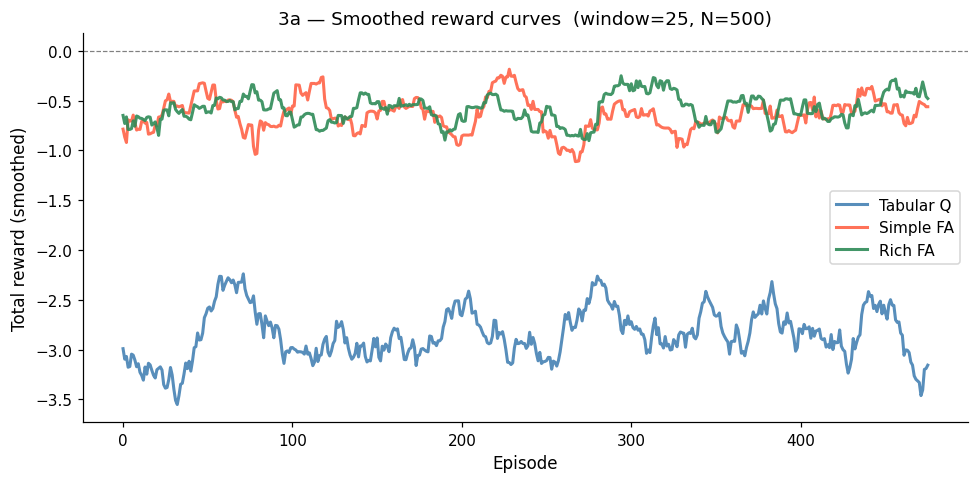

In [6]:
# ─── Plot 1: Smoothed reward curves ─────────────────────────────────────────
W = 25
fig, ax = plt.subplots(figsize=(9, 4.5))
for _, name, col in AGENTS_INFO:
    r = eval_stats[name]['rewards']
    ax.plot(np.convolve(r, np.ones(W)/W, mode='valid'),
            label=name, color=col, lw=2.0, alpha=0.9)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Total reward (smoothed)', fontsize=11)
ax.set_title(f'3a — Smoothed reward curves  (window={W}, N={N_EVAL})', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

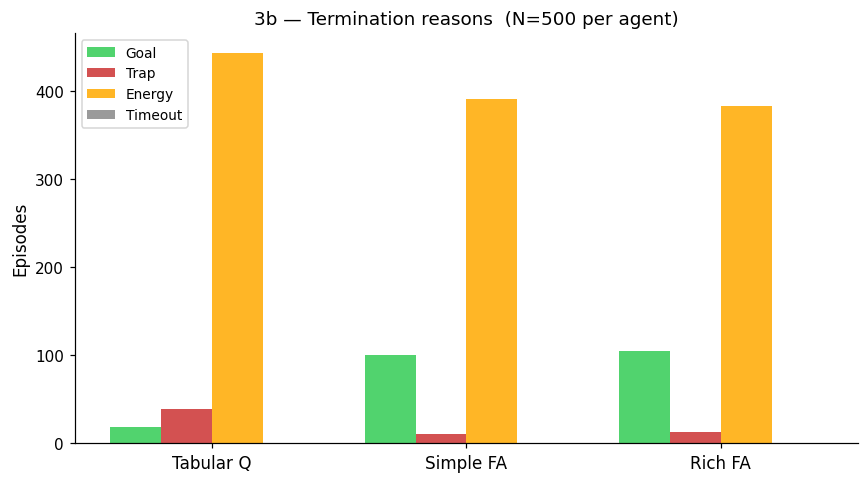

In [7]:
# ─── Plot 2: Termination reason bar chart ───────────────────────────────────
cats   = ['goal', 'trap', 'energy', 'timeout']
c_clrs = ['#33cc55', '#cc3333', '#ffaa00', '#888888']
names  = [n for _, n, _ in AGENTS_INFO]
x      = np.arange(len(names))
bw     = 0.2

fig, ax = plt.subplots(figsize=(8, 4.5))
for ci, (cat, cc) in enumerate(zip(cats, c_clrs)):
    vals = [Counter(eval_stats[n]['outcomes'])[cat] for n in names]
    ax.bar(x + ci * bw, vals, bw, label=cat.capitalize(), color=cc, alpha=0.85)
ax.set_xticks(x + 1.5 * bw)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Episodes', fontsize=11)
ax.set_title(f'3b — Termination reasons  (N={N_EVAL} per agent)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

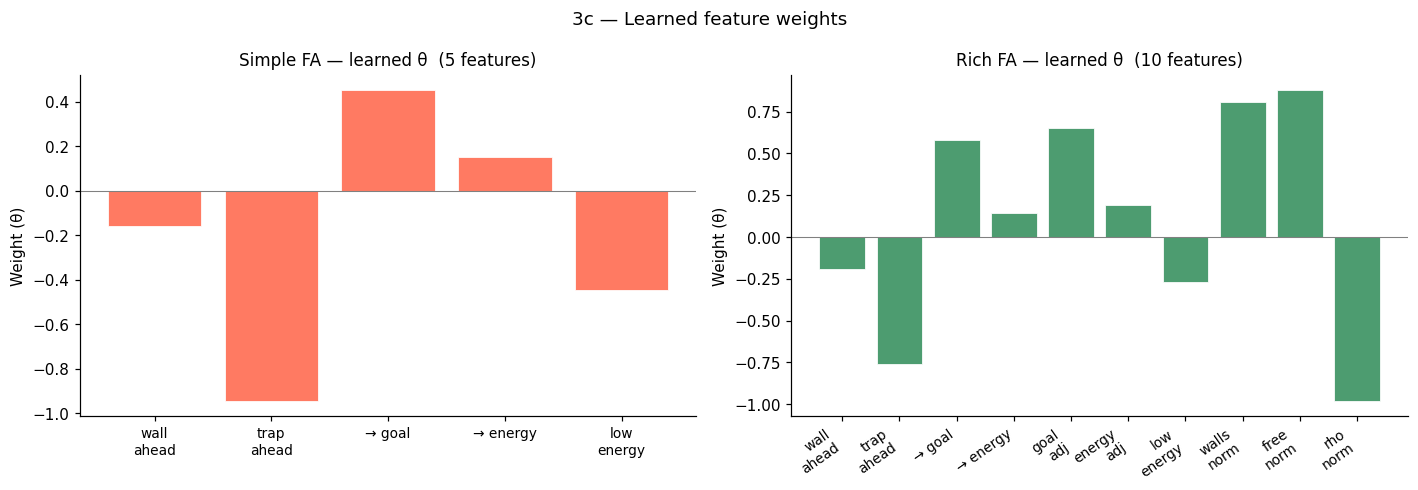

In [8]:
# ─── Plot 3: Learned weights θ ──────────────────────────────────────────────
simple_lbls = ['wall\nahead', 'trap\nahead', '→ goal', '→ energy', 'low\nenergy']
rich_lbls   = ['wall\nahead', 'trap\nahead', '→ goal', '→ energy',
               'goal\nadj', 'energy\nadj', 'low\nenergy',
               'walls\nnorm', 'free\nnorm', 'rho\nnorm']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
xs = np.arange(len(agent_simple.theta))
ax.bar(xs, agent_simple.theta, color='tomato', alpha=0.85, edgecolor='white', lw=0.6)
ax.set_xticks(xs); ax.set_xticklabels(simple_lbls, fontsize=9)
ax.axhline(0, color='gray', lw=0.7)
ax.set_ylabel('Weight (θ)', fontsize=10)
ax.set_title('Simple FA — learned θ  (5 features)', fontsize=11)

ax = axes[1]
xs = np.arange(len(agent_rich.theta))
ax.bar(xs, agent_rich.theta, color='seagreen', alpha=0.85, edgecolor='white', lw=0.6)
ax.set_xticks(xs)
ax.set_xticklabels(rich_lbls, fontsize=9, rotation=35, ha='right')
ax.axhline(0, color='gray', lw=0.7)
ax.set_ylabel('Weight (θ)', fontsize=10)
ax.set_title('Rich FA — learned θ  (10 features)', fontsize=11)

fig.suptitle('3c — Learned feature weights', fontsize=12)
plt.tight_layout()
plt.show()